*GeoPlants Dataset*

**MileStone 2**

## Load Dataset

In [58]:
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os 
from sklearn.model_selection import GroupKFold
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import geopandas as gpd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score
### Import the created function
from src.utils import merge_metadata_data

In [2]:
## Path names
path_train = "dataset/train_join_agg.parquet"
path_test = "dataset/test_df.parquet"
ecoregions = "dataset/ecoregions/ser_l93.shp"

In [3]:
## Standard Training dataset load 
df = pd.read_parquet(path_train, engine='fastparquet')

## ETL on the dataset
## select index 
df.set_index("surveyId",inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

## X, y
Xtrain = df.drop(columns=columns_to_drop)
y = df[['predict']]


In [4]:
df.shape

(13501, 53)

In [14]:
## Read test
df_test = pd.read_parquet(path_train, engine='fastparquet')

## Set index 
df_test.set_index('surveyId',inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

# ## X, y
X_test = df_test.drop(columns=columns_to_drop)
ytest = df_test[['predict']]

In [6]:
df.shape, df_test.shape

((13501, 53), (13501, 53))

## Pre Processing

### Data Cleaning

In [7]:
## pre process the data from a single function
## cleaner notebook
from src.preprocess import big_preprocessing_step, big_preprocessing_step_test

##pre process the dataset
X = big_preprocessing_step(Xtrain)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 96% percentile of the Pop2010: 2147483647.0
 The 96% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [9]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

In [10]:
X.shape, y.shape

((13501, 39), (13501, 1))

We need to also pre **processing the test df** to fill some nan values but using the train data to input the mean and median

In [8]:
Xtest = big_preprocessing_step_test(X_test, Xtrain, X)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 98% percentile of the Pop2010: 2147483647.0
 The 98% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [13]:
print(Xtest.columns.difference(X.columns))
Xtest.columns == X.columns

Index([], dtype='object')


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

### Pre-Processing

- StandarScaler
- OneHotEncoder

In [15]:
## Name cols
cat_cols = ["landcover_LandCover"]
not_cat_cols = [col for col in X.columns if col not in cat_cols]

numeric_features = not_cat_cols
categorical_features = cat_cols 

## Numeric features
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)


## Categorical Features
categorical_transformer = Pipeline(
                steps=[
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ##("selector", SelectPercentile(chi2, percentile=50)),
                ]
)

## Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [16]:
# Convert to DataFrame
X_transformed_df = pd.DataFrame(preprocessor.fit_transform(X),
                                columns=preprocessor.get_feature_names_out(),
                                index=X.index)


In [17]:
X_transformed_df

,num__average_Bio1,num__average_Bio2,num__average_Bio3,num__average_Bio4,num__average_Bio5,num__average_Bio6,num__average_Bio7,num__average_Bio8,num__average_Bio9,num__average_Bio10,...,cat__landcover_LandCover_5.0,cat__landcover_LandCover_8.0,cat__landcover_LandCover_9.0,cat__landcover_LandCover_10.0,cat__landcover_LandCover_11.0,cat__landcover_LandCover_12.0,cat__landcover_LandCover_13.0,cat__landcover_LandCover_14.0,cat__landcover_LandCover_16.0,cat__landcover_LandCover_17.0
surveyId,,,,,,,,,,,,,,,,,,,,,
333,0.347195,0.260223,0.401941,-0.783924,0.240344,0.530852,-0.408877,0.014173,0.601191,0.108783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
410,-0.137349,0.332205,0.401941,1.111207,0.167383,-0.400396,0.660988,-0.551047,-1.425111,0.108783,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
779,0.011741,0.116260,0.401941,-0.015829,0.057941,0.170369,-0.150633,-0.345513,-0.992833,-0.005940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,-0.137349,-0.099684,0.401941,0.066002,-0.124463,0.020168,-0.150633,-0.448280,-1.046868,-0.120663,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015,0.719922,0.836075,0.401941,1.352980,1.517168,0.140329,1.361934,1.118923,0.979434,1.179532,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-1.218257,0.188242,0.401941,-0.216687,-1.218883,-0.911081,-0.113742,1.195998,-1.722302,-1.306135,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3917646,1.539921,-0.027703,0.401941,0.246402,1.736052,1.131658,0.365853,0.784929,1.155046,1.676665,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3917824,-0.100077,-0.027703,0.401941,0.039965,-0.124463,0.080248,-0.224417,-0.396896,0.533647,-0.082422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cross-Validation Strategy

In [13]:
from sklearn.model_selection import GroupKFold

In [40]:
## concat dataset
Xx = pd.concat([X,df['GRECO']],axis=1).reset_index()
Xx = pd.concat([Xx,y], axis=1)

dict_train = {}
kfold = GroupKFold(n_splits=4,
                    random_state=420, shuffle=True
                   )

for i, (train_idx, test_idx) in enumerate(kfold.split(df['speciesId'],
                                                      df['predict'],
                                                      groups=df['GRECO'])):
    new_dict={}
    new_dict['train'] = train_idx
    new_dict['test']  = test_idx
    dict_train[i] = new_dict

for i in dict_train:
    print(f"    GFold: {i} - Train: {len(dict_train[i]['train'])} | Test:{len(dict_train[i]['test'])}")
for i in dict_train:   
    print(f"GFold: {i}  | Positive Rate: Train {y.iloc[dict_train[i]['train']]['predict'].mean():.3f} | Test: {y.iloc[dict_train[i]['test']]['predict'].mean():.3f} ")

    GFold: 0 - Train: 9461 | Test:4040
    GFold: 1 - Train: 8172 | Test:5329
    GFold: 2 - Train: 12162 | Test:1339
    GFold: 3 - Train: 10708 | Test:2793
GFold: 0  | Positive Rate: Train 0.432 | Test: 0.518 
GFold: 1  | Positive Rate: Train 0.537 | Test: 0.337 
GFold: 2  | Positive Rate: Train 0.475 | Test: 0.302 
GFold: 3  | Positive Rate: Train 0.401 | Test: 0.677 


In [19]:
## load the ecoregion
import re
path = 'dataset/ecoregions/ser_l93.shp'
ecogdf = gpd.read_file(path)

## Create a new column
ecogdf['GRECO'] = ecogdf['codeser'].apply(lambda x:re.findall(r'^(.+?)\d+$', x))
ecogdf['GRECO'] = ecogdf['GRECO'].apply(lambda x:x[0])

## Drop inconsistent values
ecogdf.drop(index=ecogdf.loc[ecogdf['codeser']=='-1'].index, axis=0, inplace=True)

## Convert to 4326 ## Match plant species
## Aggregate into the zones
ecogdf_4326 = ecogdf.to_crs("EPSG:4326").dissolve(by='GRECO')

GroupFold: 0
GRECO
J      3723
B      2269
C      1606
D+E     732
H       607
A       524
Name: count, dtype: int64
predict
0    5373
1    4088
Name: count, dtype: int64
GroupFold: 1
GRECO
B      2269
G      2118
F      1406
D+E     732
H       607
A       524
I+K     516
Name: count, dtype: int64
predict
1    4386
0    3786
Name: count, dtype: int64
GroupFold: 2
GRECO
J      3723
B      2269
G      2118
C      1606
F      1406
A       524
I+K     516
Name: count, dtype: int64
predict
0    6386
1    5776
Name: count, dtype: int64
GroupFold: 3
GRECO
J      3723
G      2118
C      1606
F      1406
D+E     732
H       607
I+K     516
Name: count, dtype: int64
predict
0    6418
1    4290
Name: count, dtype: int64


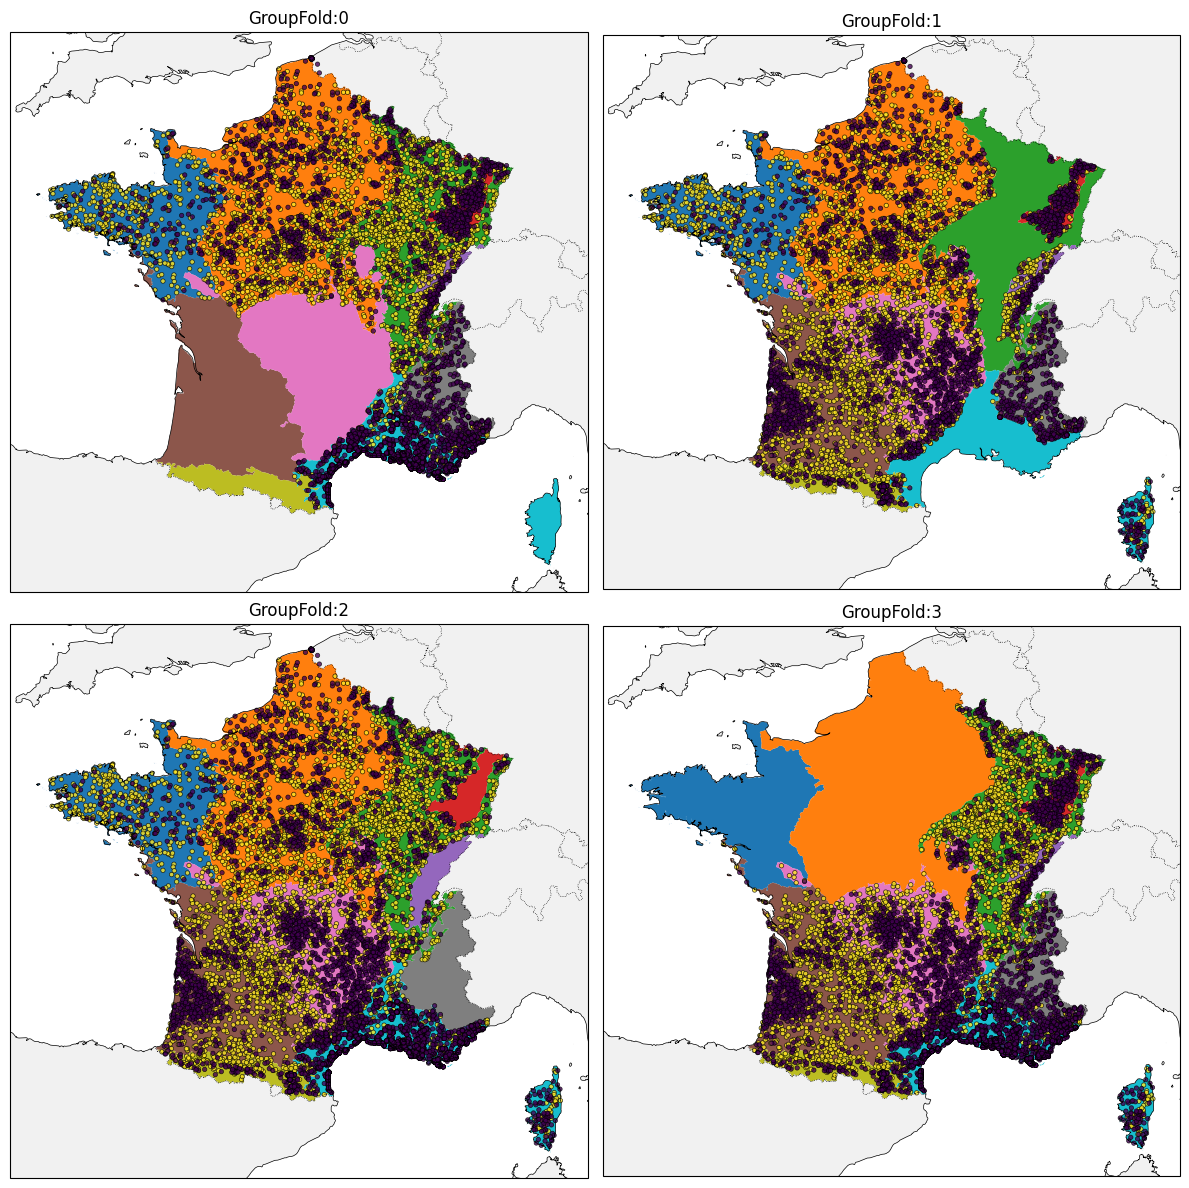

In [20]:
## Plot to see it how the samples are being distributed
dff = df.iloc[dict_train[i]['train']]
gdf = gpd.GeoDataFrame(
                        dff,
                        geometry = gpd.points_from_xy(dff["lon"],
                                                     dff["lat"]),
                        crs="EPSG:4326"
)

fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                       )
ax = ax.flatten()
for i in dict_train.keys():
    ## select the df 
    dff = df.iloc[dict_train[i]['train']]
    print(f"GroupFold: {i}")
    print(dff['GRECO'].value_counts())
    print(dff['predict'].value_counts())
    gdf = gpd.GeoDataFrame(dff,
                            geometry = gpd.points_from_xy(dff["lon"],
                                                        dff["lat"]),
                            crs="EPSG:4326"
    )
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax[i].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.5) 
    
    ## plot the ecoregion
    ecogdf_4326.plot(column=ecogdf_4326.index,
                    ax=ax[i],
                    legend=False)

    gdf.plot(
        column='predict',
        cmap='viridis',
        legend=False,
        ax=ax[i],
        markersize=10,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    ax[i].set_title(f"GroupFold:{i}")


plt.tight_layout()

## Evaluating Different Models

In [86]:
from sklearn.model_selection import cross_validate
from src.inference import evaluate_with_group_kfold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from src.plot import plot_cm

ImportError: cannot import name 'plot_cm' from 'src.plot' (/mnt/d/desktop/copernicus/classes/3-semester/ml/species/src/plot.py)

In [ ]:
## Stardard X,y and Group
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment

**Logistic Regression**

In [71]:

# Pipe
clf = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=0))
])

## Evaluate
scores_lgt = evaluate_with_group_kfold(clf,
                                       X,
                                       y_vec,
                                       groups)


In [ ]:
## Create the df from the score dictionary 
df_scores = pd.DataFrame(scores_lgt)

## Compute the total confusion matrix
total_cm = np.sum(df_scores["confusion_matrix"].to_list(), axis=0)

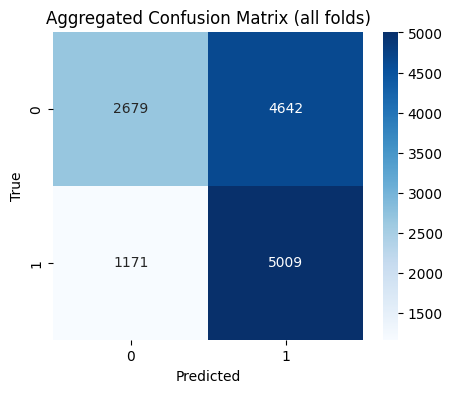

In [84]:
plot_cf(total_cm)

In [ ]:
## function to evaluate with GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

def evaluate_with_group_kfold(estimator, X, y, groups, random_state=420, plot_cm=True, verbose=False, **GK_kwargs):
    """
    args:
        estimator: an sklearn estimator or Pipeline with 'fit' and 'predict' (and ideally predict_proba)
        X:pd.DataFrame.  Raw df, preprocessor should be inside pipeline to avoid leakage
        y: array-like (1D) or DataFrame with single column "predict" column 
        groups: pd.Series. Series extracted from the df which is the aggregating denominator.
        kwargs: sklearn.model_selection.GroupKfold parameters.
    """
    ## (n,1) array shape
    y_arr = np.asarray(y).ravel()
    
    ## GroupKFold 
    kfold = GroupKFold(random_state=random_state,
                       n_splits=4,
                       shuffle=True,
                       **GK_kwargs)
    
    confusion_matrices = []
    scores = {
        'recall': [], 'precision': [], 'f1': [], 
        'accuracy': [], 'balanced_accuracy': [], 'roc_auc': [],
        'confusion_matrix': []
    }

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y_arr, groups=groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]

        # Fit
        estimator.fit(X_train, y_train)

        # Predict
        y_pred = estimator.predict(X_test)

        # Probabilities (for ROC AUC)
        y_score = None
        if hasattr(estimator, "predict_proba"):
            try:
                y_score = estimator.predict_proba(X_test)[:, 1]
            except Exception:
                y_score = None
        elif hasattr(estimator, "decision_function"):
            try:
                y_score = estimator.decision_function(X_test)
            except Exception:
                y_score = None

        # Metrics
        scores['recall'].append(recall_score(y_test, y_pred, average='weighted'))
        scores['precision'].append(precision_score(y_test, y_pred, average='weighted'))
        scores['f1'].append(f1_score(y_test, y_pred, average='weighted'))
        scores['accuracy'].append(accuracy_score(y_test, y_pred))
        scores['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred))

        
        ## Calc ROC-AUC
        if y_score is not None and len(np.unique(y_test)) > 1:
            try:
                roc = roc_auc_score(y_test, y_score)
                scores['roc_auc'].append(roc)
            except Exception:
                roc = None

        ## CM
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        confusion_matrices.append(cm)
        scores['confusion_matrix'].append(cm)

        if verbose:
            print(classification_report(y_test, y_pred, zero_division=0))

    # if plot_cm:
    #     plt.figure(figsize=(5,4))
    #     sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    #     plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Aggregated Confusion Matrix (all folds)')
    #     plt.show()

    return scores


In [65]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build pipeline: preprocessor must be the ColumnTransformer
clf = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=0))
])

# y[['predict']] 
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment

res_lr, cm = evaluate_with_group_kfold(clf, X, y_vec, groups)


In [68]:
res_lr['confusion_matrix']

[array([[1131,  817],
        [ 457, 1635]]),
 array([[ 603, 2932],
        [ 246, 1548]]),
 array([[710, 225],
        [123, 281]]),
 array([[ 235,  668],
        [ 345, 1545]])]

Fold 0 — acc:0.8031, prec:0.3395, rec:0.4743, f1:0.3957, roc_auc:0.7646869828148631
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.34      0.47      0.40       506

    accuracy                           0.80      3723
   macro avg       0.63      0.66      0.64      3723
weighted avg       0.83      0.80      0.82      3723

Fold 1 — acc:0.7058, prec:0.6583, rec:0.9110, f1:0.7643, roc_auc:0.7649837143765053
              precision    recall  f1-score   support

           0       0.83      0.48      0.61      1616
           1       0.66      0.91      0.76      1776

    accuracy                           0.71      3392
   macro avg       0.74      0.70      0.69      3392
weighted avg       0.74      0.71      0.69      3392

Fold 2 — acc:0.6858, prec:0.6605, rec:0.7776, f1:0.7143, roc_auc:0.7470189901886368
              precision    recall  f1-score   support

           0       0.72      0.59      

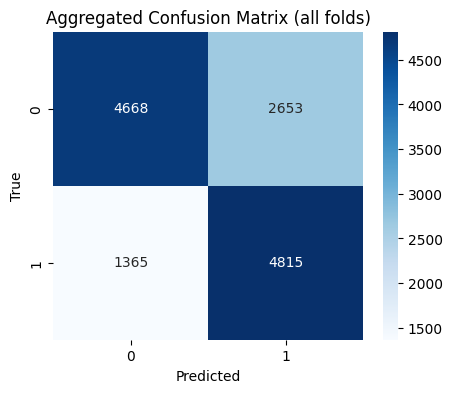

In [15]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
])

res_rf = evaluate_with_group_kfold(clf, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6873, prec:0.2303, rec:0.5553, f1:0.3256, roc_auc:0.6772853823745149
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      3217
           1       0.23      0.56      0.33       506

    accuracy                           0.69      3723
   macro avg       0.57      0.63      0.56      3723
weighted avg       0.82      0.69      0.73      3723

Fold 1 — acc:0.7022, prec:0.6600, rec:0.8896, f1:0.7578, roc_auc:0.7487789266680046
              precision    recall  f1-score   support

           0       0.80      0.50      0.61      1616
           1       0.66      0.89      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.73      0.69      0.69      3392
weighted avg       0.73      0.70      0.69      3392

Fold 2 — acc:0.6826, prec:0.6572, rec:0.7764, f1:0.7119, roc_auc:0.7495856877793708
              precision    recall  f1-score   support

           0       0.72      0.59      

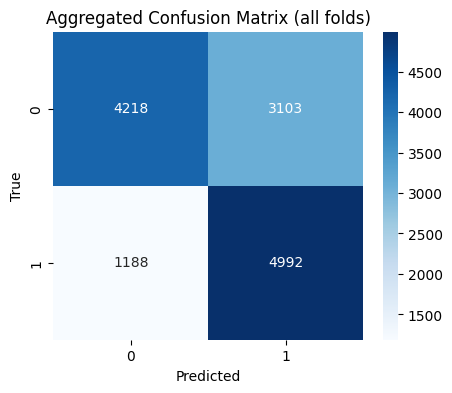

In [16]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

clf_gb = Pipeline([
    ("preproc", preprocessor),
    ("clf", HistGradientBoostingClassifier(max_iter=500, random_state=0))
])

res_gb = evaluate_with_group_kfold(clf_gb, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6992, prec:0.2512, rec:0.6126, f1:0.3563, roc_auc:0.696836285985642
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      3217
           1       0.25      0.61      0.36       506

    accuracy                           0.70      3723
   macro avg       0.59      0.66      0.58      3723
weighted avg       0.83      0.70      0.74      3723

Fold 1 — acc:0.6960, prec:0.6519, rec:0.9003, f1:0.7562, roc_auc:0.740979841227366
              precision    recall  f1-score   support

           0       0.81      0.47      0.60      1616
           1       0.65      0.90      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.73      0.69      0.68      3392
weighted avg       0.73      0.70      0.68      3392

Fold 2 — acc:0.6494, prec:0.6474, rec:0.6714, f1:0.6592, roc_auc:0.7028348233111242
              precision    recall  f1-score   support

           0       0.65      0.63      0.

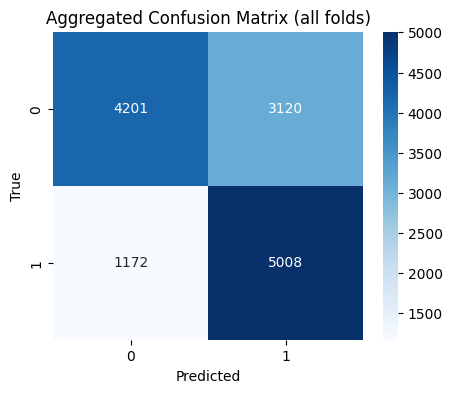

In [18]:
# SVC
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

clf_svc = Pipeline([
    ("preproc", preprocessor),
    ("clf", SVC(probability=True, kernel='rbf', C=1.0, random_state=0))
])

res_svc = evaluate_with_group_kfold(clf_svc, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.6355, prec:0.1923, rec:0.5257, f1:0.2816, roc_auc:0.6265639187075578
              precision    recall  f1-score   support

           0       0.90      0.65      0.76      3217
           1       0.19      0.53      0.28       506

    accuracy                           0.64      3723
   macro avg       0.54      0.59      0.52      3723
weighted avg       0.80      0.64      0.69      3723

Fold 1 — acc:0.6819, prec:0.6533, rec:0.8361, f1:0.7335, roc_auc:0.7173930389238248
              precision    recall  f1-score   support

           0       0.74      0.51      0.61      1616
           1       0.65      0.84      0.73      1776

    accuracy                           0.68      3392
   macro avg       0.70      0.67      0.67      3392
weighted avg       0.69      0.68      0.67      3392

Fold 2 — acc:0.6197, prec:0.6084, rec:0.6931, f1:0.6480, roc_auc:0.647573514941947
              precision    recall  f1-score   support

           0       0.64      0.54      0

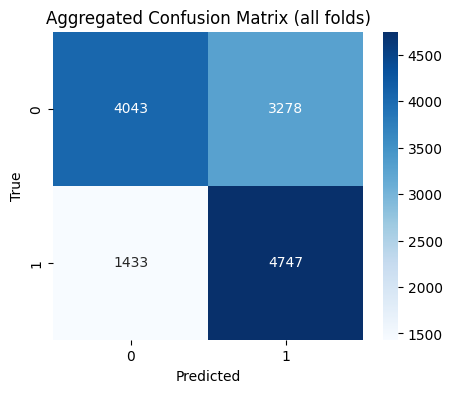

In [19]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

clf_knn = Pipeline([
    ("preproc", preprocessor),
    ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

res_knn = evaluate_with_group_kfold(clf_knn, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.4993, prec:0.1471, rec:0.5593, f1:0.2329, roc_auc:0.4911380499593931
              precision    recall  f1-score   support

           0       0.88      0.49      0.63      3217
           1       0.15      0.56      0.23       506

    accuracy                           0.50      3723
   macro avg       0.51      0.52      0.43      3723
weighted avg       0.78      0.50      0.57      3723

Fold 1 — acc:0.6436, prec:0.5992, rec:0.9640, f1:0.7390, roc_auc:0.7287163207452503
              precision    recall  f1-score   support

           0       0.88      0.29      0.44      1616
           1       0.60      0.96      0.74      1776

    accuracy                           0.64      3392
   macro avg       0.74      0.63      0.59      3392
weighted avg       0.73      0.64      0.60      3392

Fold 2 — acc:0.6100, prec:0.5820, rec:0.8081, f1:0.6767, roc_auc:0.6760775983244778
              precision    recall  f1-score   support

           0       0.68      0.41      

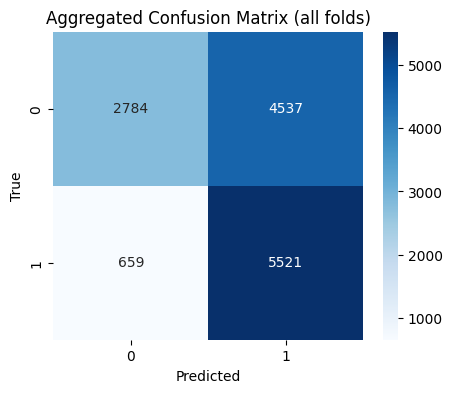

In [20]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

clf_nb = Pipeline([
    ("preproc", preprocessor),
    ("clf", GaussianNB())
])

res_nb = evaluate_with_group_kfold(clf_nb, X, y_vec, groups, n_splits=4)


Fold 0 — acc:0.5966, prec:0.1463, rec:0.4071, f1:0.2153, roc_auc:0.5152423329127253
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      3217
           1       0.15      0.41      0.22       506

    accuracy                           0.60      3723
   macro avg       0.51      0.52      0.47      3723
weighted avg       0.77      0.60      0.66      3723

Fold 1 — acc:0.7043, prec:0.6595, rec:0.8998, f1:0.7611, roc_auc:0.7239116436981536
              precision    recall  f1-score   support

           0       0.82      0.49      0.61      1616
           1       0.66      0.90      0.76      1776

    accuracy                           0.70      3392
   macro avg       0.74      0.69      0.69      3392
weighted avg       0.73      0.70      0.69      3392

Fold 2 — acc:0.6150, prec:0.6230, rec:0.6021, f1:0.6124, roc_auc:0.6545753563295943
              precision    recall  f1-score   support

           0       0.61      0.63      

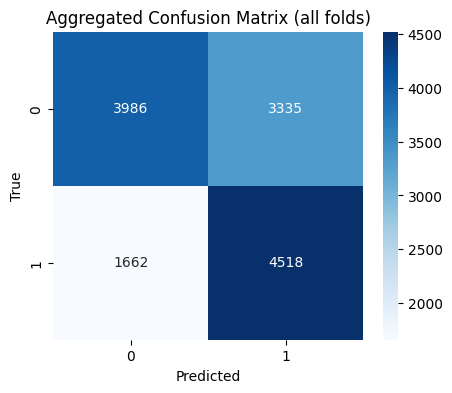

In [21]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

clf_ab = Pipeline([
    ("preproc", preprocessor),
    ("clf", AdaBoostClassifier(n_estimators=200, random_state=0))
])

res_ab = evaluate_with_group_kfold(clf_ab, X, y_vec, groups, n_splits=4)


## ploting

In [23]:
import pandas as pd
import matplotlib.pyplot as plt


results = {
    'Model': ['Logistic Regression', 'Random Forest', 'GBoost', 'SVC', 'KNN', 'GaussianNB', 'AdaBoost'],
    'Accuracy': [0.561769, 0.699100, 0.682296, 0.681633, 0.651949,0.621233,  0.629945 ]
}

df_results = pd.DataFrame(results)


# ## ,
#     'Precision': [0.5964, 0.612, 0.631, 0.59, 0.57],
#     'Recall': [0.7226, 0.74, 0.756, 0.70, 0.68],
#     'F1': [0.6513, 0.667, 0.681, 0.63, 0.60],
#     'ROC_AUC': [0.7109, 0.726, 0.742, 0.702, 0.695]

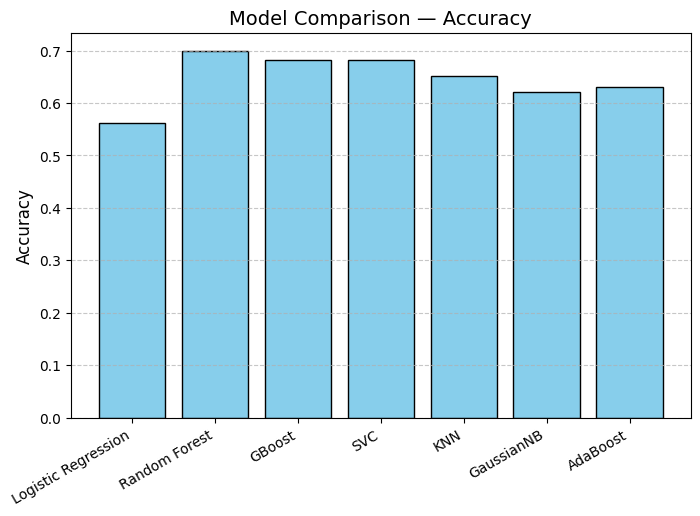

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(df_results['Model'], df_results['Accuracy'], color='skyblue', edgecolor='black')
plt.title('Model Comparison — Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Feature Selection for better accuracy

Fold 0: perm importances shape = (39,), raw features = 39
Fold 1: perm importances shape = (39,), raw features = 39
Fold 2: perm importances shape = (39,), raw features = 39
Fold 3: perm importances shape = (39,), raw features = 39
Fold 4: perm importances shape = (39,), raw features = 39
Fold 5: perm importances shape = (39,), raw features = 39


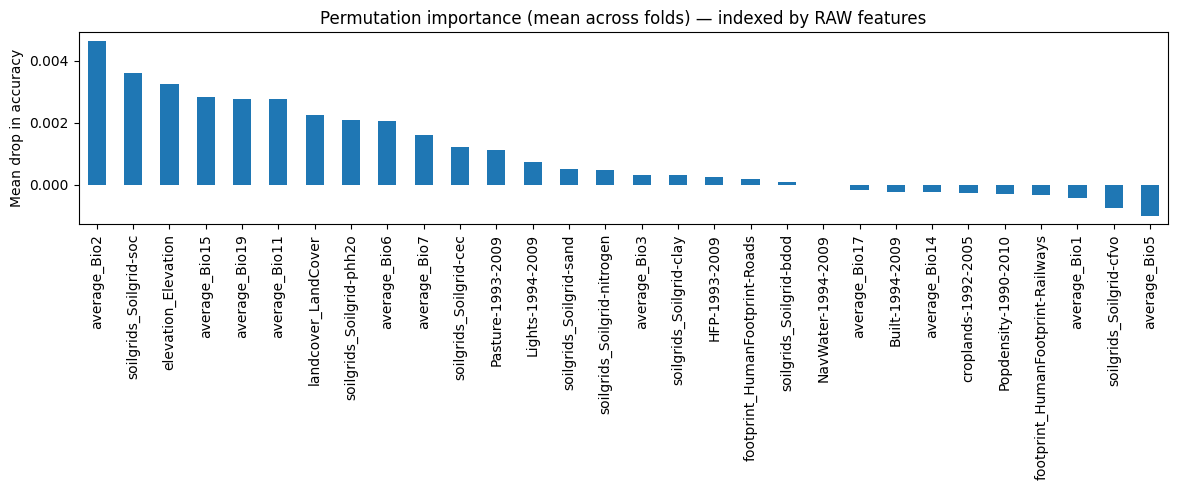

average_Bio2                         0.004635
soilgrids_Soilgrid-soc               0.003594
elevation_Elevation                  0.003247
average_Bio15                        0.002841
average_Bio19                        0.002768
average_Bio11                        0.002752
landcover_LandCover                  0.002240
soilgrids_Soilgrid-phh2o             0.002095
average_Bio6                         0.002066
average_Bio7                         0.001591
soilgrids_Soilgrid-cec               0.001227
Pasture-1993-2009                    0.001126
Lights-1994-2009                     0.000733
soilgrids_Soilgrid-sand              0.000502
soilgrids_Soilgrid-nitrogen          0.000469
average_Bio3                         0.000314
soilgrids_Soilgrid-clay              0.000310
HFP-1993-2009                        0.000262
footprint_HumanFootprint-Roads       0.000188
soilgrids_Soilgrid-bdod              0.000069
NavWater-1994-2009                   0.000000
average_Bio17                     

In [17]:
# Permutation importance per fold (GroupKFold) and average
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

n_splits = 6
gkf = GroupKFold(n_splits=n_splits)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names
perm_vals = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)

    # compute permutation importance ON THE RAW X_test (pipeline handles preprocessing inside)
    r = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1, scoring='accuracy')
    print(f"Fold {fold_i}: perm importances shape = {r.importances_mean.shape}, raw features = {len(raw_feat_names)}")
    perm_vals.append(r.importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))




In [23]:
# Dropping low/negative features and evaluate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# threshold (0 means dropping negative and zero)
threshold = 0.0
keep_features = perm_series[perm_series > threshold].index.tolist()
drop_features = [f for f in X.columns if f not in keep_features]

print(f"Keeping {len(keep_features)} features, dropping {len(drop_features)} features")

X_reduced = X[keep_features].copy()
groups_reduced = df.loc[X_reduced.index, 'GRECO']

# build preprocessor for reduced set
cat_cols = [c for c in X_reduced.columns if c.startswith('landcover') or X_reduced[c].dtype == 'object']
num_cols = [c for c in X_reduced.columns if c not in cat_cols]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc_reduced = ColumnTransformer([("num", numeric_transformer, num_cols),
                                     ("cat", categorical_transformer, cat_cols)], remainder='drop')

pipe_reduced = Pipeline([("preproc", preproc_reduced), ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))])

# Evaluate original (on full X) and reduced (X_reduced)
print("Evaluating original RF on full X:")
res_full = evaluate_with_group_kfold(Pipeline([("preproc", preprocessor), ("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))]), X, y_vec, groups=df.loc[X.index,'GRECO'], n_splits=4, plot_cm=False)

print("\nEvaluating RF on reduced feature set:")
res_reduced = evaluate_with_group_kfold(pipe_reduced, X_reduced, y_vec, groups=groups_reduced, n_splits=8, plot_cm=False)

print("\nMean accuracy full: {:.4f}".format(res_full['summary_df']['accuracy'].mean()))
print("Mean accuracy reduced: {:.4f}".format(res_reduced['summary_df']['accuracy'].mean()))


Keeping 20 features, dropping 19 features
Evaluating original RF on full X:
Fold 0 — acc:0.7994, prec:0.3329, rec:0.4743, f1:0.3912, roc_auc:0.7620478411993596
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.47      0.39       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.64      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.7070, prec:0.6589, rec:0.9127, f1:0.7653, roc_auc:0.7644617660668094
              precision    recall  f1-score   support

           0       0.83      0.48      0.61      1616
           1       0.66      0.91      0.77      1776

    accuracy                           0.71      3392
   macro avg       0.75      0.70      0.69      3392
weighted avg       0.74      0.71      0.69      3392

Fold 2 — acc:0.6894, prec:0.6643, rec:0.7782, f1:0.7168, roc_auc:0.7486370568721712
              prec

## Trying to drop Human footprint

In [44]:
X.shape

(13501, 39)

In [18]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

X_mod shape: (13501, 30)
Fold 0 — acc:0.7983, prec:0.3277, rec:0.4605, f1:0.3829, roc_auc:0.7550282528219034
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.46      0.38       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.63      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.6549, prec:0.6549, rec:0.9980, f1:0.7908, roc_auc:0.6292378079643938
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       786
           1       0.65      1.00      0.79      1483

    accuracy                           0.65      2269
   macro avg       0.66      0.50      0.40      2269
weighted avg       0.66      0.65      0.52      2269

Fold 2 — acc:0.7158, prec:0.6826, rec:0.7336, f1:0.7072, roc_auc:0.7922504850665752
              precision    recall  f1-score   support

           0  

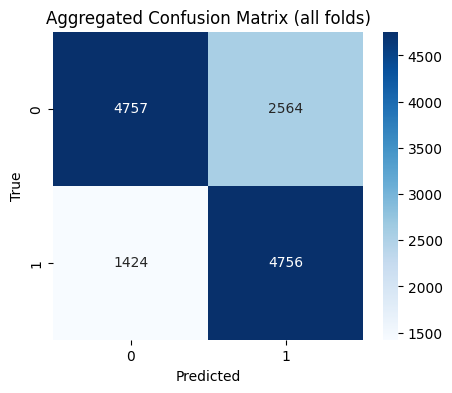

In [22]:
hf_cols = [
'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'
]

X_mod = X.drop(columns=[c for c in hf_cols if c in X.columns]).copy()
groups_mod = df.loc[X_mod.index, 'GRECO']
print("X_mod shape:", X_mod.shape)

# Rebuild a local preprocessor from X_mod columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

cat_cols = [c for c in X_mod.columns if c.startswith('landcover') or X_mod[c].dtype == 'object']
num_cols = [c for c in X_mod.columns if c not in cat_cols]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preproc_mod = ColumnTransformer([("num", numeric_transformer, num_cols),
                                 ("cat", categorical_transformer, cat_cols)], remainder='drop')

pipe_mod = Pipeline([("preproc", preproc_mod), ("clf", RandomForestClassifier(n_estimators=1500, random_state=0, n_jobs=-1))])

res_rf_mod = evaluate_with_group_kfold(pipe_mod, X_mod, y_vec, groups=groups_mod, n_splits=9)


## Dummy Classifier

Fold 0 — acc:0.7983, prec:0.3277, rec:0.4605, f1:0.3829, roc_auc:0.7550282528219034
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3217
           1       0.33      0.46      0.38       506

    accuracy                           0.80      3723
   macro avg       0.62      0.66      0.63      3723
weighted avg       0.83      0.80      0.81      3723

Fold 1 — acc:0.6549, prec:0.6549, rec:0.9980, f1:0.7908, roc_auc:0.6292378079643938
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       786
           1       0.65      1.00      0.79      1483

    accuracy                           0.65      2269
   macro avg       0.66      0.50      0.40      2269
weighted avg       0.66      0.65      0.52      2269

Fold 2 — acc:0.7158, prec:0.6826, rec:0.7336, f1:0.7072, roc_auc:0.7922504850665752
              precision    recall  f1-score   support

           0       0.75      0.70      

<Figure size 800x500 with 0 Axes>

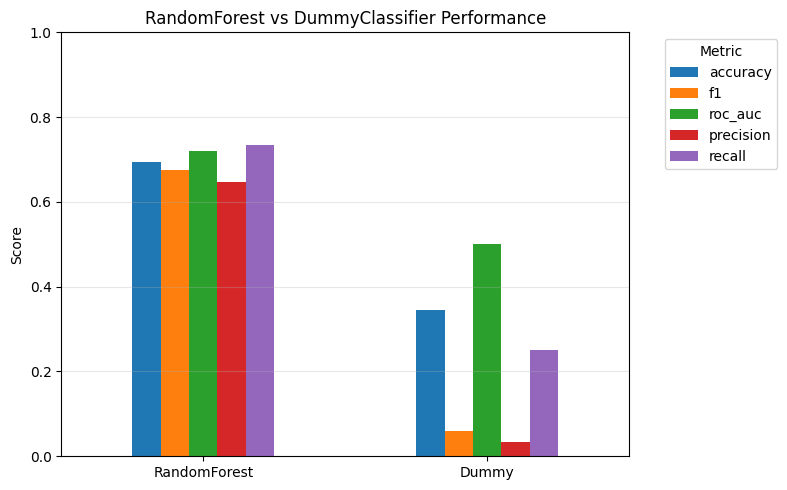

In [25]:
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Evaluate RandomForest
rf_res = evaluate_with_group_kfold(pipe_mod, X, y, groups=df.loc[X.index, 'GRECO'], n_splits=7, plot_cm=False)
rf_summary = rf_res["summary_df"].mean()

# Evaluate DummyClassifier
dummy_pipe = Pipeline([
    ("preproc", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent"))  # predicts majority class
])

dummy_res = evaluate_with_group_kfold(dummy_pipe, X, y, groups=df.loc[X.index, 'GRECO'], n_splits=4, plot_cm=False)
dummy_summary = dummy_res["summary_df"].mean()

# Combine results into DataFrame
compare_df = pd.DataFrame({
    "RandomForest": rf_summary,
    "Dummy": dummy_summary
})

print(compare_df)

# Visualization
metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]
plt.figure(figsize=(8, 5))
compare_df.loc[metrics].T.plot(kind="bar", figsize=(8,5), rot=0)
plt.title("RandomForest vs DummyClassifier Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 